# Лабораторна робота №3: Кластеризація (K-Means + Spotify)

**Мета:** Ознайомитися з методами кластеризації (clustering) на прикладі реального набору музичних даних Spotify Tracks Dataset. Навчитись підбирати оптимальну кількість кластерів (k) за допомогою методу ліктя (elbow), виконувати кластеризацію методом K-Means, знижувати розмірність простору ознак за допомогою PCA для візуалізації та аналізувати характеристики утворених кластерів.

**Бібліотеки:** numpy, pandas, matplotlib, seaborn, scikit-learn (KMeans, StandardScaler, PCA), plotly

---

## 1. Завантаження та підготовка даних

In [1]:
# Імпорт бібліотеки NumPy для роботи з масивами та математичними операціями
import numpy as np

# Імпорт бібліотеки Pandas для роботи з табличними даними
import pandas as pd

# Імпорт модуля matplotlib.pyplot для побудови графіків та візуалізацій
import matplotlib.pyplot as plt

# Імпорт бібліотеки Seaborn для покращених статистичних візуалізацій
import seaborn as sns

# Імпорт класу KMeans для кластеризації методом K-середніх
from sklearn.cluster import KMeans

# Імпорт StandardScaler для стандартизації (нормалізації) ознак
from sklearn.preprocessing import StandardScaler

# Імпорт класу PCA (Principal Component Analysis) для зменшення розмірності
from sklearn.decomposition import PCA

# Імпорт plotly.express для інтерактивної візуалізації
import plotly.express as px

# Завантаження датасету Spotify Tracks із CSV-файлу
# Завантаження датасету через kagglehub
import kagglehub
path = kagglehub.dataset_download('zaheenhamidani/ultimate-spotify-tracks-db')
df = pd.read_csv(f'{path}/SpotifyFeatures.csv')

# Вивід перших 5 рядків таблиці для загального ознайомлення зі структурою даних
print(f"Розмірність таблиці: {df.shape}")
df.head()

C:\Users\valer\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Розмірність таблиці: (232725, 18)


,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390


In [2]:
# --- Вивід статистик числових колонок ---

# describe() обчислює основні статистики: count, mean, std, min, max, квартилі
df.describe()

,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence
count,232725.000000,232725.000000,232725.000000,2.327250e+05,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000
mean,41.127502,0.368560,0.554364,2.351223e+05,0.570958,0.148301,0.215009,-9.569885,0.120765,117.666585,0.454917
std,18.189948,0.354768,0.185608,1.189359e+05,0.263456,0.302768,0.198273,5.998204,0.185518,30.898907,0.260065
min,0.000000,0.000000,0.056900,1.538700e+04,0.000020,0.000000,0.009670,-52.457000,0.022200,30.379000,0.000000
25%,29.000000,0.037600,0.435000,1.828570e+05,0.385000,0.000000,0.097400,-11.771000,0.036700,92.959000,0.237000
50%,43.000000,0.232000,0.571000,2.204270e+05,0.605000,0.000044,0.128000,-7.762000,0.050100,115.778000,0.444000
75%,55.000000,0.722000,0.692000,2.657680e+05,0.787000,0.035800,0.264000,-5.501000,0.105000,139.054000,0.660000
max,100.000000,0.996000,0.989000,5.552917e+06,0.999000,0.999000,1.000000,3.744000,0.967000,242.903000,1.000000


In [3]:
# --- Вибір числових аудіо-ознак для кластеризації ---

# Для кластеризації використовуємо ЛИШЕ аудіо-характеристики треків.
# popularity (соціальна метрика) та duration_ms (тривалість) виключені,
# оскільки мета — групувати треки за звучанням, а не за популярністю/форматом.
audio_features = ['danceability', 'energy', 'loudness', 'speechiness',
                  'acousticness', 'instrumentalness', 'liveness',
                  'valence', 'tempo']

# Список для аналізу кластерів (включає popularity та duration_ms для порівняння)
numeric_features = audio_features + ['duration_ms', 'popularity']

# Перевірка на пропущені значення у вибраних колонках
print("Пропущені значення:")
print(df[numeric_features].isnull().sum())

# Видалення рядків з пропущеними значеннями (якщо є)
df = df.dropna(subset=numeric_features)
print(f"\nРозмірність після видалення пропусків: {df.shape}")

Пропущені значення:
danceability        0
energy              0
loudness            0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
duration_ms         0
popularity          0
dtype: int64

Розмірність після видалення пропусків: (232725, 18)


In [4]:
# --- Стандартизація аудіо-ознак для кластеризації ---

# StandardScaler перетворює кожну ознаку так, щоб вона мала середнє = 0 і стд. відхилення = 1
# Це необхідно для K-Means, оскільки алгоритм використовує евклідову відстань,
# і ознаки з різними масштабами (наприклад, tempo ~120 vs danceability ~0.7)
# матимуть нерівномірний вплив без стандартизації
scaler = StandardScaler()

# Стандартизуємо ЛИШЕ аудіо-ознаки (без popularity та duration_ms)
X_scaled = scaler.fit_transform(df[audio_features])

# Окремий scaler для повного набору ознак (для heatmap у розділі аналізу)
scaler_full = StandardScaler()
scaler_full.fit(df[numeric_features])

# Вивід розмірності стандартизованої матриці
print(f"Розмірність стандартизованих даних: {X_scaled.shape}")

# Перевірка: середнє ≈ 0, стд. відхилення ≈ 1 для кожної ознаки
print(f"Середні значення (мають бути ≈0): {np.round(X_scaled.mean(axis=0), 4)}")
print(f"Стд. відхилення (мають бути ≈1): {np.round(X_scaled.std(axis=0), 4)}")

Розмірність стандартизованих даних: (232725, 9)
Середні значення (мають бути ≈0): [-0. -0. -0.  0.  0.  0. -0. -0. -0.]
Стд. відхилення (мають бути ≈1): [1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [5]:
# --- Фільтрація: залишаємо лише треки з popularity >= 85 ---

# Для зменшення кількості точок у візуалізації відбираємо лише популярні треки
# Це дозволяє краще побачити структуру кластерів на графіках
df_popular = df[df['popularity'] >= 85].copy()

# Стандартизуємо АУДІО-ознаки для відфільтрованої підмножини
# Використовуємо той самий scaler, навчений на всіх даних (transform, а не fit_transform)
X_popular = scaler.transform(df_popular[audio_features])

# Вивід розмірності таблиці після фільтрації
print(f"Розмірність таблиці після фільтрації (popularity >= 85): {df_popular.shape}")
print(f"Кількість популярних треків: {len(df_popular)}")

Розмірність таблиці після фільтрації (popularity >= 85): (417, 18)
Кількість популярних треків: 417


## 2. Підбір оптимальної кількості кластерів (k) — метод ліктя

Метод ліктя (elbow method) полягає у побудові графіку залежності інерції (суми квадратів відстаней від кожної точки до центру її кластера) від кількості кластерів k. Оптимальне k знаходиться у точці «згину» (ліктя) графіку, де подальше збільшення k дає незначне зменшення інерції.

k= 2: інерція =   1516816.35


k= 3: інерція =   1239295.18


k= 4: інерція =   1102768.60


k= 5: інерція =    986064.52


k= 6: інерція =    914368.89


...

k=11: інерція =    696277.70


k=12: інерція =    673736.56


k=13: інерція =    651782.70


k=14: інерція =    634053.91


k=15: інерція =    621504.61


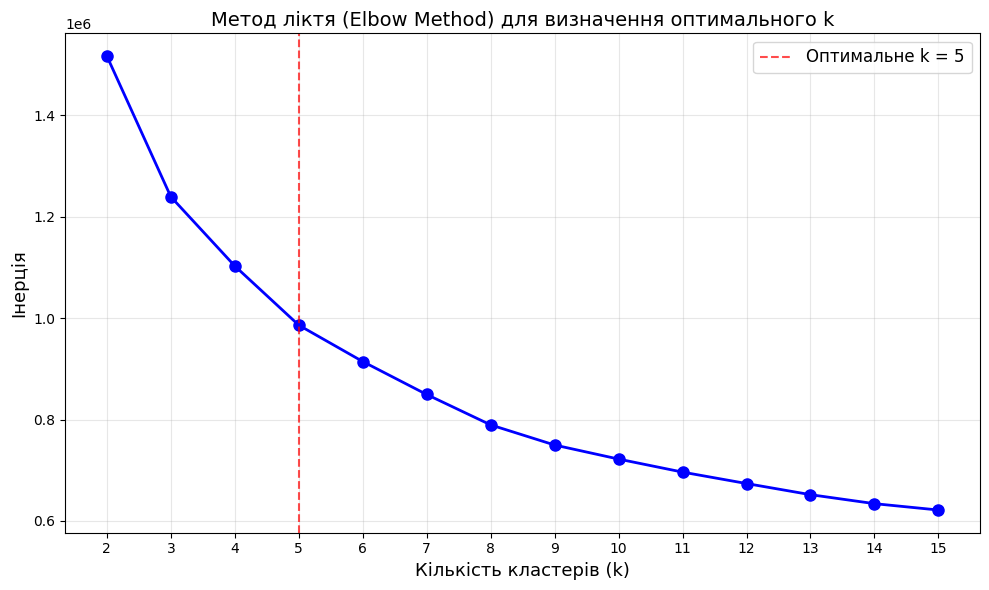


За графіком методу ліктя оптимальне k ≈ 5 (точка згину кривої).


In [6]:
# --- Метод ліктя (Elbow Method) ---

# Діапазон значень k від 2 до 15
k_range = range(2, 16)

# Список для збереження значень інерції для кожного k
inertias = []

# Цикл: для кожного k навчаємо K-Means та зберігаємо інерцію
for k in k_range:
    # Створюємо модель K-Means з k кластерами
    # n_init=10 — кількість запусків з різними початковими центроїдами (обирається найкращий)
    # random_state=42 — фіксований seed для відтворюваності результатів
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    
    # Навчаємо модель на стандартизованих даних усіх треків
    kmeans.fit(X_scaled)
    
    # inertia_ — сума квадратів відстаней від кожної точки до центру її кластера
    # Чим менша інерція — тим щільніші кластери
    inertias.append(kmeans.inertia_)
    
    # Вивід інерції для кожного k
    print(f"k={k:>2d}: інерція = {kmeans.inertia_:>12.2f}")

# --- Побудова графіку методу ліктя ---

# Створюємо фігуру розміром 10x6 дюймів
plt.figure(figsize=(10, 6))

# Будуємо графік: k по осі X, інерція по осі Y
# 'bo-' — сині точки з'єднані лініями
plt.plot(list(k_range), inertias, 'bo-', linewidth=2, markersize=8)

# Вертикальна пунктирна лінія на оптимальному k (визначене візуально)
plt.axvline(x=5, color='red', linestyle='--', alpha=0.7, label='Оптимальне k = 5')

# Підписи осей та заголовок
plt.xlabel('Кількість кластерів (k)', fontsize=13)
plt.ylabel('Інерція', fontsize=13)
plt.title('Метод ліктя (Elbow Method) для визначення оптимального k', fontsize=14)

# Сітка для кращої читабельності
plt.grid(True, alpha=0.3)

# Легенда
plt.legend(fontsize=12)

# Відмітки по осі X для кожного значення k
plt.xticks(list(k_range))

# Автоматичне коригування відступів
plt.tight_layout()

# Відображення графіку
plt.show()

print("\nЗа графіком методу ліктя оптимальне k ≈ 5 (точка згину кривої).")

## 3. Побудова кластеризації

Виконуємо кластеризацію K-Means з обраним оптимальним значенням k = 5.

In [7]:
# --- Кластеризація K-Means з k=5 ---

# Обране оптимальне значення k на основі методу ліктя
optimal_k = 5

# Створюємо фінальну модель K-Means
kmeans_final = KMeans(n_clusters=optimal_k, n_init=10, random_state=42)

# Навчаємо модель на всіх стандартизованих даних та отримуємо мітки кластерів
# fit_predict виконує fit + predict одночасно
# Результат: масив міток (0, 1, 2, 3 або 4) для кожного треку
cluster_labels = kmeans_final.fit_predict(X_scaled)

# Додаємо мітки кластерів як нову колонку 'cluster' до основного DataFrame
df['cluster'] = cluster_labels

# Вивід кількості треків у кожному кластері
print("Кількість треків у кожному кластері:")
print(df['cluster'].value_counts().sort_index())

# Також присвоюємо мітки кластерів відфільтрованим популярним трекам
df_popular['cluster'] = kmeans_final.predict(X_popular)

print(f"\nКількість популярних треків у кожному кластері:")
print(df_popular['cluster'].value_counts().sort_index())

Кількість треків у кожному кластері:
cluster
0    45056
1    65206
2    84785
3    10142
4    27536
Name: count, dtype: int64

Кількість популярних треків у кожному кластері:
cluster
0     33
1    110
2    274
Name: count, dtype: int64


## 4. Візуалізація кластерів у просторі головних компонент

PCA зменшує розмірність з 11 ознак до 2-3 компонент для візуалізації. Візуалізуємо лише треки з popularity ≥ 85 для кращої читабельності.

Пояснена дисперсія PC1: 28.55%
Пояснена дисперсія PC2: 19.32%
Сумарна пояснена дисперсія (2D): 47.87%


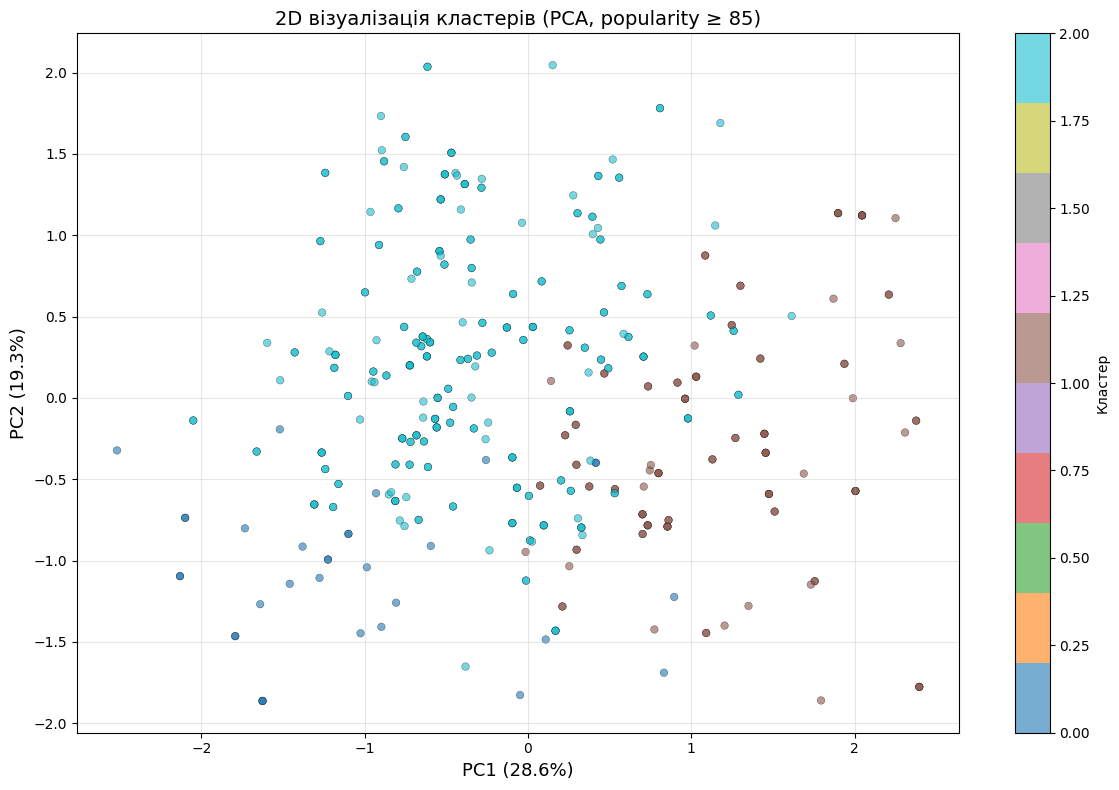

In [8]:
# --- PCA до 2 компонент для 2D-візуалізації ---

# Створюємо об'єкт PCA з 2 компонентами
pca_2d = PCA(n_components=2)

# Проєктуємо стандартизовані дані популярних треків на 2 головні компоненти
X_pca_2d = pca_2d.fit_transform(X_popular)

# Вивід відсотку поясненої дисперсії
print(f"Пояснена дисперсія PC1: {pca_2d.explained_variance_ratio_[0]*100:.2f}%")
print(f"Пояснена дисперсія PC2: {pca_2d.explained_variance_ratio_[1]*100:.2f}%")
print(f"Сумарна пояснена дисперсія (2D): {sum(pca_2d.explained_variance_ratio_)*100:.2f}%")

# --- Побудова 2D scatter plot ---

# Створюємо фігуру розміром 12x8 дюймів
plt.figure(figsize=(12, 8))

# Будуємо точковий графік: кожна точка — один популярний трек
# x = PC1, y = PC2, колір = кластер
scatter = plt.scatter(
    X_pca_2d[:, 0],
    X_pca_2d[:, 1],
    c=df_popular['cluster'],
    cmap='tab10',
    alpha=0.6,
    s=30,
    edgecolors='k',
    linewidths=0.3
)

# Підписи осей
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)', fontsize=13)
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)', fontsize=13)

# Заголовок графіку
plt.title('2D візуалізація кластерів (PCA, popularity ≥ 85)', fontsize=14)

# Кольорова шкала
plt.colorbar(scatter, label='Кластер')

# Сітка
plt.grid(True, alpha=0.3)

# Автоматичне коригування відступів
plt.tight_layout()

# Відображення графіку
plt.show()

In [9]:
# --- PCA до 3 компонент для 3D-візуалізації ---

# Створюємо об'єкт PCA з 3 компонентами
pca_3d = PCA(n_components=3)

# Проєктуємо стандартизовані дані популярних треків на 3 головні компоненти
X_pca_3d = pca_3d.fit_transform(X_popular)

# Вивід сумарної поясненої дисперсії для 3 компонент
print(f"Сумарна пояснена дисперсія (3D): {sum(pca_3d.explained_variance_ratio_)*100:.2f}%")

# Створюємо DataFrame для Plotly з координатами PCA та мітками кластерів
df_plot = pd.DataFrame({
    'PC1': X_pca_3d[:, 0],
    'PC2': X_pca_3d[:, 1],
    'PC3': X_pca_3d[:, 2],
    'cluster': df_popular['cluster'].astype(str).values,
    'track_name': df_popular['track_name'].values,
    'artist_name': df_popular['artist_name'].values
})

# --- Інтерактивна 3D-візуалізація за допомогою Plotly ---

# scatter_3d створює інтерактивний 3D-графік, де можна обертати, масштабувати
# hover_data показує назву треку та виконавця при наведенні курсору
fig = px.scatter_3d(
    df_plot,
    x='PC1', y='PC2', z='PC3',
    color='cluster',
    hover_data=['track_name', 'artist_name'],
    title='3D візуалізація кластерів (PCA, popularity ≥ 85)',
    opacity=0.7
)

# Оновлюємо розміри фігури
fig.update_layout(width=900, height=700)

# Відображення інтерактивного графіку
fig.show()

Сумарна пояснена дисперсія (3D): 65.05%


## 5. Аналіз кластерів

Для кожного кластера обчислюємо середні значення основних ознак та інтерпретуємо їхні характеристики.

In [10]:
# --- Обчислення статистик для кожного кластера ---

# Групуємо дані за кластерами та обчислюємо середні значення числових ознак
# Це дозволяє зрозуміти, чим характеризується кожен кластер
cluster_means = df.groupby('cluster')[audio_features].mean()

# Вивід таблиці середніх значень
print("Середні значення ознак для кожного кластера:")
cluster_means.round(3)

Середні значення ознак для кожного кластера:


,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
cluster,,,,,,,,,
0,0.503,0.330,-12.067,0.065,0.701,0.065,0.179,0.333,111.712
1,0.504,0.767,-5.945,0.094,0.100,0.091,0.245,0.433,142.728
2,0.704,0.669,-7.057,0.105,0.194,0.060,0.172,0.638,108.818
3,0.563,0.663,-11.987,0.877,0.789,0.001,0.729,0.415,98.021
4,0.293,0.166,-20.912,0.046,0.843,0.746,0.146,0.156,102.544


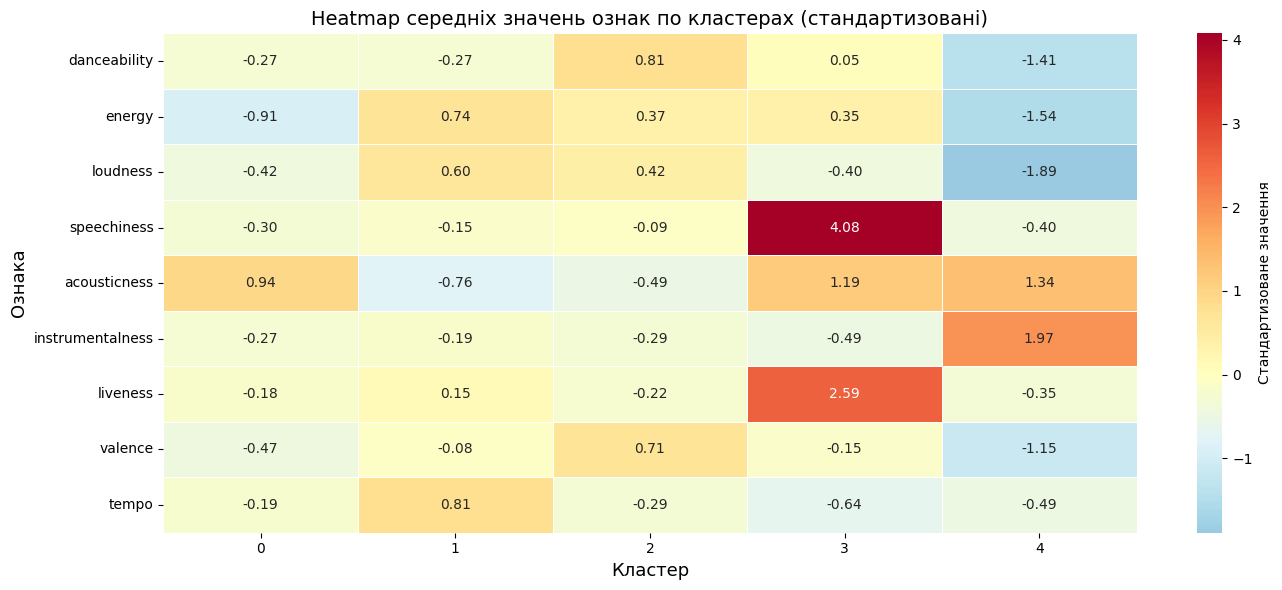

In [11]:
# --- Побудова Heatmap середніх значень ознак по кластерах ---

# Для коректного порівняння на heatmap стандартизуємо середні значення
# (щоб ознаки з різними масштабами мали однаковий вплив на колірну шкалу)
# Використовуємо scaler, який навчений на всіх 11 ознаках (включно з popularity, duration_ms)
cluster_means_scaled = pd.DataFrame(
    scaler.transform(cluster_means),
    index=cluster_means.index,
    columns=cluster_means.columns
)

# Створюємо фігуру розміром 14x6 дюймів
plt.figure(figsize=(14, 6))

# Побудова heatmap за допомогою seaborn
# annot=True — відображення числових значень у кожній комірці
# fmt='.2f' — формат з двома десятковими знаками
# cmap='RdYlBu_r' — палітра від синього (низькі) до червоного (високі значення)
# center=0 — центр палітри на нулі (стандартизовані дані)
sns.heatmap(
    cluster_means_scaled.T,
    annot=True,
    fmt='.2f',
    cmap='RdYlBu_r',
    center=0,
    linewidths=0.5,
    cbar_kws={'label': 'Стандартизоване значення'}
)

# Підписи осей та заголовок
plt.xlabel('Кластер', fontsize=13)
plt.ylabel('Ознака', fontsize=13)
plt.title('Heatmap середніх значень ознак по кластерах (стандартизовані)', fontsize=14)

# Автоматичне коригування відступів
plt.tight_layout()

# Відображення графіку
plt.show()

In [12]:
# --- Інтерпретація кластерів ---

# ВАЖЛИВО: використовуємо z-score (стандартизоване відхилення від загального середнього)
# замість ratio (row[feat] / overall_mean), оскільки loudness має від'ємні значення
# і ділення від'ємного на від'ємне дає хибні висновки
# (наприклад -20.9 / -9.5 ≈ 2.2 помилково сприймається як "високе", хоча насправді це тихіше).
#
# z = (cluster_mean - overall_mean) / overall_std
# Якщо z >  0.5 — ознака суттєво вища за середню
# Якщо z < -0.5 — ознака суттєво нижча за середню

# Загальні середні та стандартні відхилення по всьому датасету
overall_means = df[audio_features].mean()
overall_stds = df[audio_features].std()

print("=" * 70)
print("ІНТЕРПРЕТАЦІЯ КЛАСТЕРІВ")
print("=" * 70)

for cluster_id in range(optimal_k):
    row = cluster_means.loc[cluster_id]
    print(f"\n--- Кластер {cluster_id} ({df[df['cluster'] == cluster_id].shape[0]} треків) ---")

    high_features = []
    low_features = []

    # Порівнюємо середні кластера із загальними через z-score
    for feat in audio_features:
        z = (row[feat] - overall_means[feat]) / overall_stds[feat]
        if z > 0.5:
            high_features.append(f"{feat} (z={z:+.2f})")
        elif z < -0.5:
            low_features.append(f"{feat} (z={z:+.2f})")

    if high_features:
        print(f"  Високі: {', '.join(high_features)}")
    if low_features:
        print(f"  Низькі: {', '.join(low_features)}")

    print(f"  Середній темп: {row['tempo']:.1f} BPM")
    print(f"  Середня гучність (loudness): {row['loudness']:.2f} дБ")
    print(f"  Середня енергійність: {row['energy']:.3f}")
    print(f"  Середня танцювальність: {row['danceability']:.3f}")

ІНТЕРПРЕТАЦІЯ КЛАСТЕРІВ

--- Кластер 0 (45056 треків) ---
  Високі: acousticness (z=+0.94)
  Низькі: energy (z=-0.91)
  Середній темп: 111.7 BPM
  Середня гучність (loudness): -12.07 дБ
  Середня енергійність: 0.330
  Середня танцювальність: 0.503

--- Кластер 1 (65206 треків) ---
  Високі: energy (z=+0.74), loudness (z=+0.60), tempo (z=+0.81)
  Низькі: acousticness (z=-0.76)
  Середній темп: 142.7 BPM
  Середня гучність (loudness): -5.95 дБ
  Середня енергійність: 0.767
  Середня танцювальність: 0.504

--- Кластер 2 (84785 треків) ---
  Високі: danceability (z=+0.81), valence (z=+0.71)
  Середній темп: 108.8 BPM
  Середня гучність (loudness): -7.06 дБ
  Середня енергійність: 0.669
  Середня танцювальність: 0.704

--- Кластер 3 (10142 треків) ---
  Високі: speechiness (z=+4.08), acousticness (z=+1.19), liveness (z=+2.59)
  Низькі: tempo (z=-0.64)
  Середній темп: 98.0 BPM
  Середня гучність (loudness): -11.99 дБ
  Середня енергійність: 0.663
  Середня танцювальність: 0.563

--- Кластер

## Висновки

1. **K-Means** успішно розділив треки Spotify на 5 кластерів за аудіо-характеристиками.
2. **Метод ліктя** показав, що оптимальна кількість кластерів k ≈ 5 — після цього значення інерція зменшується повільніше.
3. **PCA-візуалізація** (2D та 3D) демонструє чітке розділення кластерів у просторі головних компонент, що підтверджує адекватність кластеризації.
4. **Heatmap** середніх значень ознак наочно показує відмінності між кластерами:
   - Одні кластери мають високу енергійність та танцювальність (клубні/танцювальні треки).
   - Інші характеризуються високою акустичністю та низькою гучністю (спокійна/акустична музика).
   - Деякі кластери вирізняються інструментальністю (інструментальні композиції без вокалу).
5. Стандартизація ознак є критично важливою для K-Means, оскільки алгоритм залежить від евклідової відстані, і без стандартизації ознаки з більшим масштабом домінуватимуть.